# 선문대학교 컴퓨터공학부
# 2022243101 최완우

### House Prices 데이터를 이용한 주택 가격 등급 분류

데이터셋 : House Prices : Advanced Regression Techniques
사용 파일 : train.csv

# 1. 데이터 불러오기 및 탐색

In [48]:
# 1.1 train.csv를 불러오시오.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')

In [49]:
# 1.2 데이터의 행/열 개수를 확인하시오.
print("- 데이터 크기(행, 열) :")
df.shape

- 데이터 크기(행, 열) :


(1460, 81)

In [50]:
# 1.3 각 변수의 자료형을 확인하시오.
print("- 각 변수의 자료형 : ")
print(df.head())

- 각 변수의 자료형 : 
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0   20

In [51]:
# 1.4 결측치 개수를 확인하고, 결측치가 많은 상위 10개 변수를 제시하시오.
print("- 결측치 개수 : ")
missing_values = df.isnull().sum()
print(missing_values)

print("\n- 결측치가 많은 상위 10개 변수 : ")
missing_values = df.isnull().sum().sort_values(ascending = False)
print(missing_values.head(10))

- 결측치 개수 : 
Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

- 결측치가 많은 상위 10개 변수 : 
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64


- SalePrice 기초통계량 :
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

- SalerPrice 분포 : 


Text(0, 0.5, 'Frequency')

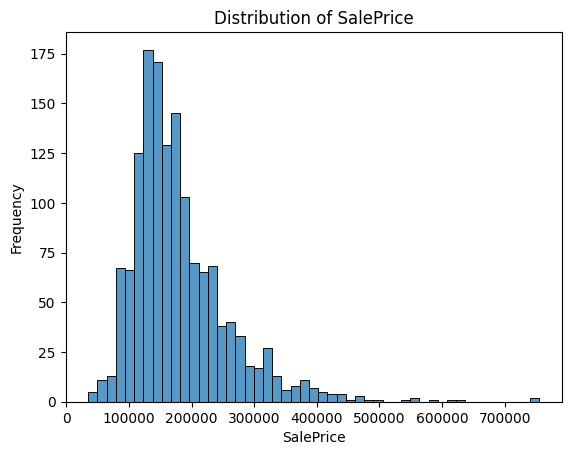

In [52]:
# 1.5 SalePrice 의 기초통계량과 분포를 확인하시오.
print("- SalePrice 기초통계량 :")
print(df['SalePrice'].describe())

# 분포도(히스토그램) 그리기
print("\n- SalerPrice 분포 : ")
sns.histplot(df['SalePrice'])

plt.title('Distribution of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Frequency')

In [53]:
# 1.6 SalePrice 를 기준으로 이진 레이블을 생성하시오.
median_price = df['SalePrice'].median()         # 기준점 : 중앙값
y = (df['SalePrice'] >= median_price).astype(int)   # 중앙값이상 : 1, 중앙값이하 : 0

print(f"- SalePrice 중앙값 : {median_price} ---")
print(f"\n- 생성된 타킷 변수(y)의 클래스 분포 : {y.value_counts()}")

- SalePrice 중앙값 : 163000.0 ---

- 생성된 타킷 변수(y)의 클래스 분포 : SalePrice
1    732
0    728
Name: count, dtype: int64


### 제출 내용
- 데이터 크기 : 1460행 / 81열
- 결측치 상위 10개 변수 :

    PoolQC(1453)            수영장 품질

    MiscFeature(1406)       기타 특수 시설

    Alley(1369)             골목길 접근 유형

    Fence(1179)             울타리 품질

    MasVnrType(872)         외벽 마감재 유형

    FireplaceQu(690)        벽난로 품질

    LotFrontage(259)        도로 인접 길이

    GarageQual(81)          참고 품질

    GarageFinish(81)        차고 내부 마감 상태

    GarageType(81)          차고 유형
- SalePrice 분포 해석 : SalePrice 값이 높을 수록 Frequency 값이 낮아지는 비대칭 형태의 분포를 띄고 있다.
- 클래스 생성 기준 설명 : 분포도를 통해 평균값으로 계산하면 '보통 집값'보다 훨씬 높게 끌어올려지는 왜곡이 발생한다. 그래서 중앙값을 사용하여 소수의 비싼 집값에 휘둘리지 않고 훨씬 안정적인 주택 가격을 나눌 수 있다.

# 2. 전처리

In [54]:
# 7. 입력 변수 X와 타킷 변수 y를 분리하시오.
y = (df['SalePrice'] >= df['SalePrice'].median()).astype(int)
X = df.drop(columns = ['SalePrice'])  # 학습에 불필요한 'SalePrice'를 drop

print("- 데이터 분리 결과 -")
print("- 입력 변수 X의 크기 : ")
print(X.shape)
print("- 타킷 변수 y의 크기 : ")
print(y.shape)

- 데이터 분리 결과 -
- 입력 변수 X의 크기 : 
(1460, 80)
- 타킷 변수 y의 크기 : 
(1460,)


In [55]:
# 8. 식별자 역할만 하는 Id는 제거하시오.
X = X.drop(columns = ['Id'])    # 학습에 불필요한 'Id'를 drop
print("- 입력 변수 x의 크기 : ")
print(X.shape)

- 입력 변수 x의 크기 : 
(1460, 79)


In [59]:
# 9. 수치형 변수와 범주형 변수를 구분하시오.
num_cols = X.select_dtypes(include = ['int64', 'float64']).columns  # 수치형 : 정수, 실수
cat_cols = X.select_dtypes(include = ['object']).columns            # 범주형 : 문자열

C:\Users\최완우\AppData\Local\Temp\ipykernel_14972\451713800.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include = ['object']).columns            # 범주형 : 문자열


In [64]:
# 10. 결측치를 처리하시오.
# - 수치형 변수 : 중앙값으로 대체
X[num_cols] = X[num_cols].fillna(X[num_cols].median(0))
# - 범주형 변수 : 최빈값으로 대체
X[cat_cols] = X[cat_cols].fillna(X[cat_cols].mode().iloc[0])

# 결측치 존재 여부 확인
total_missing = X.isnull().sum().sum()
print("- 데이터셋 내 결측치 개수 : ")
print(total_missing)

- 데이터셋 내 결측치 개수 : 
0


C:\Users\최완우\AppData\Local\Temp\ipykernel_14972\1635031715.py:3: Pandas4Warning: Starting with pandas version 4.0 all arguments of median will be keyword-only.
  X[num_cols] = X[num_cols].fillna(X[num_cols].median(0))


In [ ]:
# 11. 범주형 변수는 One-Hot Encoding을 적용하시오.
X = pd.get_dummies(X)   # 문자열을 0과 1의 숫자 데이터로 변환

print("입력변수 X의 크기 : ")
print(X.shape)

입력변수 X의 크기 : 
(1460, 287)


### 서술형 질문
- 범주형 변수에 단순히 0, 1, 2, 3 처럼 숫자를 부여하면 왜 문제가 될 수 있는가?
    
    존재하지 않는 순서나 크기가 존재하는 것처럼 오인하게 되어 모델의 성능을 심각하게 저하시키거나 잘못된 학습 결과를 만들 수 있다.

- 결측치 처리 방식이 결과에 영향을 주는 이유는 무엇인가?
    
    결측치를 어떤 값으로 채우느냐에 따라 데이터의 원래 분포나 숨겨진 의미가 왜곡될 수 있으며 모델이 잘못된 패턴을 학습하여 최종 예측 성능이 떨어지는 결과로 이어질 수 있기 때문이다.

# 3. 데이터 분할

In [69]:
# 12. 학습 데이터와 테스트 데이터를 8:2 비율로 분할하시오.
# 13. stratify = y를 적용하시오.
# 14. random_state = 42 를 사용하시오.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

### 서술형 질문
- stratify는 왜 필요한가?

train 데이터와 test 데이터에 속한 클래스의 데이터 분포를 비율까지 맞추기 위해서 필요하다.
- 분류 문제에서 클래스 비율 유지가 중요한 이유는 무엇인가?

데이터의 클래스 비율이 균일하지 않고 하나에 치우쳐 있으면 모델이 다수의 클래스에 편향된 학습을 하여 제대로 분류하지 못하는 문제가 발생할 수 있기 때문이다.

# 4. Random Forest 실험

In [75]:
# 15. 기본 Random Forest 모델을 학습하시오.
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score

rf_basic = RandomForestClassifier(random_state = 42)
rf_basic.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [85]:
# 16. n_estimators, max_depth 를 바꿔가며 성능을 비교하시오.
# 17. 테스트 데이터에서 다음 평가지표를 계산하시오.
# Accuracy, Precision, Recall, F1-score, Confusion Matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def print_metrics(y_test, y_pred, model_name) :
    print(model_name)
    print(f"- Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"- Precision : {precision_score(y_test, y_pred):.4f}")
    print(f"- Recall : {recall_score(y_test, y_pred):.4f}")
    print(f"- F1-score : {f1_score(y_test, y_pred):.4f}")
    print(f"- Confusion Matrix : {confusion_matrix(y_test, y_pred)}")

pred_basic = rf_basic.predict(X_test)
print_metrics(y_test, pred_basic, "기본 Randon Forest")

# n_estimators = 50, max_depth = 5 로 변경
rf_test_01 = RandomForestClassifier(n_estimators = 50, max_depth = 5, random_state = 42)
rf_test_01.fit(X_train, y_train)

pred_test_01 = rf_test_01.predict(X_test)
print_metrics(y_test, pred_test_01, "\n변경_01 (n_estimators = 50, max_depth = 5) : ")

# n_estimators = 200, max_depth = 10 으로 변경
rf_test_02 = RandomForestClassifier(n_estimators = 200, max_depth = 10, random_state = 42)
rf_test_02.fit(X_train, y_train)

pred_test_02 = rf_test_02.predict(X_test)
print_metrics(y_test, pred_test_02, "\n변경_02 (n_estimators = 200, max_depth = 10) : ")

기본 Randon Forest
- Accuracy : 0.9521
- Precision : 0.9714
- Recall : 0.9315
- F1-score : 0.9510
- Confusion Matrix : [[142   4]
 [ 10 136]]

변경_01 (n_estimators = 50, max_depth = 5) : 
- Accuracy : 0.9349
- Precision : 0.9441
- Recall : 0.9247
- F1-score : 0.9343
- Confusion Matrix : [[138   8]
 [ 11 135]]

변경_02 (n_estimators = 200, max_depth = 10) : 
- Accuracy : 0.9418
- Precision : 0.9574
- Recall : 0.9247
- F1-score : 0.9408
- Confusion Matrix : [[140   6]
 [ 11 135]]


### 서술형 질문
- Random Forest는 왜 스케일링에 크게 민감하지 않은가?

    Random Forest는 Decision Tree 기반의 구조이기 때문에 데이터 간의 상대적 크기는 유지되므로 분할 지점만 조정되고 결과는 거의 같다.
- 트리 기반 모델은 왜 비선형 관계를 잘 처리할 수 있는가?

    데이터를 하나의 단순한 선형으로 나누려 하지 않고, 여러 변수에 대해 계단식으로 꼬리를 물며 조건을 잘게 쪼개어 나가기 대문이다.